In [1]:
import gseapy as gp
import pandas as pds
import scanpy as sc
import numpy as np

## Analyze DEGs from single-cell data
First: Load in your adata object (edit path as needed).

In [2]:
adata = sc.read_h5ad(
    "/Users/norawolcott/Documents/Datta Lab/data/scRNA-seq/260812/results/adata_mature_osn.h5ad"
)

output_dir = "/Users/norawolcott/Documents/Datta Lab/data/scRNA-seq/260812/results/DE analysis"

/opt/miniconda3/lib/python3.13/site-packages/anndata/_core/anndata.py:1882: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Get differential expression between groups

In [3]:
sc.tl.rank_genes_groups(
    adata,
    groupby="condition",
    groups=["GD18-preg"],
    reference="GD18-control",
    method="wilcoxon"
)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Extract DE results for specific group

In [4]:
deg_results = sc.get.rank_genes_groups_df(
    adata,
    group="GD18-preg"
)

Create a ranked gene list

In [5]:
ranked_genes = (
    deg_results
    .set_index("names")["scores"]
    .dropna()
)

Run GSEApy prerank

In [6]:
pre_res = gp.prerank(
    rnk=ranked_genes,
    gene_sets=[
        'GO_Biological_Process_2025',
        'WikiPathways_2024_Mouse',
        'MSigDB_Hallmark_2020'
    ],
    organism='mouse',
    permutation_num=1000,
    outdir=None
)

print(pre_res.res2d.head())

2026-08-20 16:19:52,110 [WARNING] Duplicated values found in preranked stats: 66.63% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


      Name                                               Term        ES  \
0  prerank  GO_Biological_Process_2025__Regulation of Endo... -0.908189   
1  prerank      WikiPathways_2024_Mouse__GPCRs Odorant WP1397  0.812133   
2  prerank  GO_Biological_Process_2025__Aortic Valve Devel... -0.860648   
3  prerank  GO_Biological_Process_2025__Negative Regulatio... -0.931368   
4  prerank  GO_Biological_Process_2025__Sodium Ion Transpo...  -0.76722   

        NES NOM p-val FDR q-val FWER p-val   Tag %  Gene %  \
0 -1.514331  0.005013       1.0      0.872    8/45   4.51%   
1  1.466084  0.004608  0.997083      0.604  20/137  12.17%   
2 -1.427869  0.022472       1.0        1.0    8/40   3.78%   
3 -1.411905  0.013812       1.0        1.0    4/26   3.91%   
4 -1.409269  0.022792       1.0        1.0   20/93   5.29%   

                                          Lead_genes  
0     Nfe2l2;Xbp1;Krit1;Pdcd4;Pdpk1;Ano6;Mapk7;Prkci  
1  Gpr137;Gpr162;Gpr158;Gpr137c;Gpr137b;Gpr108;Gp...  
2       Rbp

Run enrichment analysis

In [5]:
enr = gp.enrichr(
    gene_list=gene_list,
    gene_sets=[
        'GO_Biological_Process_2025',
        'WikiPathways_2024_Mouse',
        'MSigDB_Hallmark_2020' # technically human but used in mouse estrogen studies
    ],
    organism='mouse',
    outdir='enrichr_results'
)

enr.results.head(20)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2025,Positive Regulation of Intracellular Signal Tr...,68/652,5.758903e-07,0.001974,0,0,2.023020,29.065429,ITGB1;TRAF3IP2;SCHIP1;FGF1;ADRA1B;LITAF;IGF1R;...
1,GO_Biological_Process_2025,Extracellular Matrix Organization (GO:0030198),26/182,1.057654e-05,0.017201,0,0,2.849772,32.649469,ITGB1;COL15A1;ECM2;COL14A1;TMPRSS6;LOXL4;NID1;...
2,GO_Biological_Process_2025,Regulation of Cell Migration (GO:0030334),50/479,1.752761e-05,0.017201,0,0,2.007796,21.988848,ITGB1;PTPRT;GSK3B;CLIC4;CSF1;LDLRAD4;FGF1;CLDN...
3,GO_Biological_Process_2025,Regulation of Angiogenesis (GO:0045765),28/211,2.007740e-05,0.017201,0,0,2.617191,28.307321,ITGB1;FOXC1;GRN;SP100;PDE3B;FGF1;THBS2;CDH5;AD...
4,GO_Biological_Process_2025,Positive Regulation of Cell-Matrix Adhesion (G...,11/45,2.843672e-05,0.017860,0,0,5.492713,57.496785,GSK3B;CSF1;PLEKHA2;THY1;TEK;PLPP3;CCL28;RIN2;F...
5,GO_Biological_Process_2025,Positive Regulation of Vasculature Development...,18/109,3.393665e-05,0.017860,0,0,3.369273,34.673235,ITGB1;ANGPT4;GRN;TIE1;FGF1;ISL1;F3;HIPK2;VEGFA...
6,GO_Biological_Process_2025,Regulation of Phosphatidylinositol 3-Kinase/Pr...,28/219,3.977012e-05,0.017860,0,0,2.506498,25.396825,ITGB1;CSF1R;MSTN;MAZ;PDE3B;EFNA5;IGF1R;PPP2CA;...
7,GO_Biological_Process_2025,"Retrograde Vesicle-Mediated Transport, Golgi t...",11/47,4.401454e-05,0.017860,0,0,5.187012,52.030868,ARF4;COPB2;SCFD1;TMED10;KDELR1;GOLPH3L;COPZ2;K...
8,GO_Biological_Process_2025,Glomerulus Vasculature Development (GO:0072012),4/5,4.690291e-05,0.017860,0,0,67.602507,673.823314,ANGPT2;PECAM1;TEK;CD34
9,GO_Biological_Process_2025,Positive Regulation of Cell Motility (GO:2000147),30/249,6.594350e-05,0.022599,0,0,2.342955,22.554958,ITGB1;IGSF8;CSF1R;GRN;CSF1;SEMA3C;SEMA3D;CCDC2...


Plot

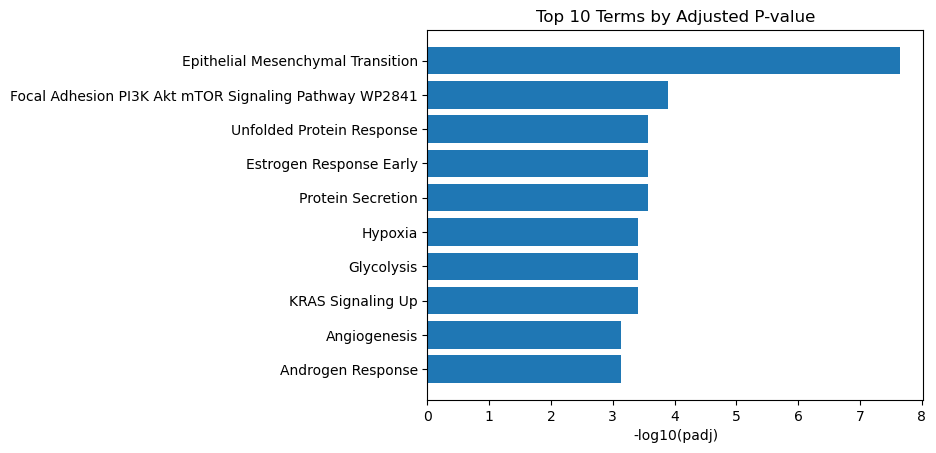

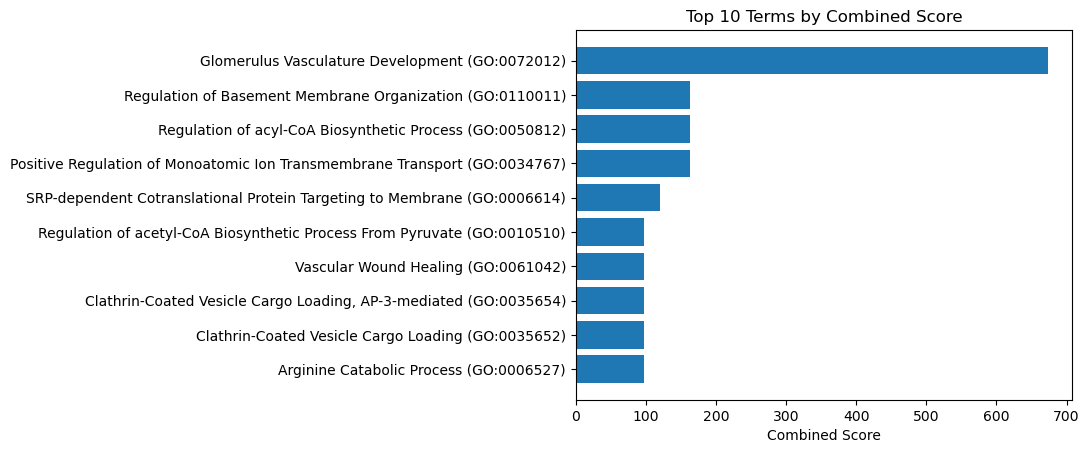

In [6]:
# First: plot bar chart ordered by p-value
top_p = enr.results.sort_values("Adjusted P-value").head(10)

plt.figure()
plt.barh(top_p["Term"], -np.log10(top_p["Adjusted P-value"]))
plt.xlabel("-log10(padj)")
plt.title("Top 10 Terms by Adjusted P-value")
plt.gca().invert_yaxis()
plt.show()


# Second: plot bar chart ordered by combined score
top_score = enr.results.sort_values("Combined Score", ascending=False).head(10)

plt.figure()
plt.barh(top_score["Term"], top_score["Combined Score"])
plt.xlabel("Combined Score")
plt.title("Top 10 Terms by Combined Score")
plt.gca().invert_yaxis()
plt.show()

Identify specifically enriched genes

In [7]:
# Copy results
res = enr.results.copy()

# Sort by significance
res = res.sort_values("Adjusted P-value")

print("\n===== TOP 15 ENRICHED TERMS (p-value) =====")
display(res[["Term", "Adjusted P-value", "Combined Score"]].head(15))

# Extract genes driving top pathways
print("\n===== GENES DRIVING TOP 15 PATHWAYS (p-value) =====")
for i in range(min(15, len(res))):
    row = res.iloc[i]
    print(f"\n{i+1}. {row['Term']}")
    print("Genes:", row["Genes"])

# Sort by Combined Score (highest first)
res = res.sort_values("Combined Score", ascending=False)

print("\n===== TOP 15 ENRICHED TERMS (combined score) =====")
display(res[["Term", "Adjusted P-value", "Combined Score"]].head(15))

# Extract genes driving top pathways
print("\n===== GENES DRIVING TOP 15 PATHWAYS (combined score) =====")
for i in range(min(15, len(res))):
    row = res.iloc[i]
    print(f"\n{i+1}. {row['Term']}")
    print("Genes:", row["Genes"])

# Steroid related terms
print("\n===== HORMONE-RELATED TERMS =====")
steroid_terms = res[
    res["Term"].str.contains("ESTROGEN|ESR|PROGESTERONE|ANDROGEN|PROLACTIN|PRL|CORTICOSTEROID|STEROID", case=False, na=False)
]

if len(steroid_terms) > 0:
    display(steroid_terms[["Term", "Adjusted P-value", "Combined Score"]])
else:
    print("No steroid-related terms found")

# Olfaction related terms
print("\n===== OLFACTION-RELATED TERMS =====")

olfaction_terms = res[
    res["Term"].str.contains(
        "OLFACT|ODOR|OLFACTORY|OSN|RECEPTOR|GPCR",
        case=False,
        na=False
    )
]

if len(olfaction_terms) > 0:
    display(olfaction_terms[["Term", "Adjusted P-value", "Combined Score"]])
else:
    print("No olfaction-related terms found")

    # Ciliary terms
print("\n===== CILIARY TERMS =====")

ciliary_terms = res[
    res["Term"].str.contains(
        "CILIUM|CILIARY|CILIA",
        case=False,
        na=False
    )
]

if len(ciliary_terms) > 0:
    display(ciliary_terms[["Term", "Adjusted P-value", "Combined Score"]])
else:
    print("No ciliary terms found")

if len(ciliary_terms) > 0:
    display(ciliary_terms[["Term", "Adjusted P-value", "Combined Score"]])

    # Extract genes driving top 15 ciliary pathways (by combined score)
    print("\n===== GENES DRIVING TOP CILIARY TERMS (combined score) =====")
    
    top_ciliary = ciliary_terms.sort_values(
        "Combined Score", ascending=False
    ).head(15)

    for i, (_, row) in enumerate(top_ciliary.iterrows(), start=1):
        print(f"\n{i}. {row['Term']}")
        print("Genes:", row["Genes"])

else:
    print("No ciliary terms found")


===== TOP 15 ENRICHED TERMS (p-value) =====


,Term,Adjusted P-value,Combined Score
3585,Epithelial Mesenchymal Transition,2.262567e-08,81.467500
3427,Focal Adhesion PI3K Akt mTOR Signaling Pathway...,1.257204e-04,35.286798
3586,Unfolded Protein Response,2.746911e-04,38.063728
3587,Estrogen Response Early,2.746911e-04,28.799887
3588,Protein Secretion,2.746911e-04,39.303559
3589,Hypoxia,3.984466e-04,24.999424
3590,Glycolysis,3.984466e-04,24.999424
3591,KRAS Signaling Up,3.984466e-04,24.999424
3592,Angiogenesis,7.445621e-04,50.750670
3593,Androgen Response,7.445621e-04,28.891127



===== GENES DRIVING TOP 15 PATHWAYS (p-value) =====

1. Epithelial Mesenchymal Transition
Genes: ITGB1;ECM2;LAMA2;PCOLCE2;HTRA1;FBLN1;THY1;THBS2;LOXL1;FBLN5;NT5E;CALD1;ABI3BP;QSOX1;CCN1;EDIL3;CAP2;POSTN;CADM1;LUM;APLP1;BGN;VEGFC;VEGFA;GREM1;COL4A2;LOX;COL4A1;ID2;COL6A2;CDH11;CALU;PMP22;FERMT2;SNTB1;FBN1

2. Focal Adhesion PI3K Akt mTOR Signaling Pathway WP2841
Genes: CHRM2;ITGB1;CSF1R;GSK3B;CHRM1;CSF1;LAMA2;FGF1;EFNA5;THBS2;ELAVL1;IGF1R;PPP2CA;GHR;RELN;PPP2R1B;CREB3L4;PDGFD;GNG7;EIF4EBP1;MAPK1;IKBKG;RAB2A;IFNAR2;PDGFRA;ANGPT4;ANGPT2;HGF;VEGFC;PPP2R5A;GNG12;OSMR;VEGFA;COL4A2;COL4A1;COL6A2;GNB1;ITGA8;ITGA6;TEK;FGF10

3. Unfolded Protein Response
Genes: ERO1A;HSPA9;EDEM1;ASNS;WIPI1;HERPUD1;VEGFA;ERN1;DNAJC3;MTHFD2;PSAT1;KHSRP;STC2;CNOT2;EIF4EBP1;SRPRA;KDELR3;ALDH18A1;TARS1

4. Estrogen Response Early
Genes: FOXC1;SLC26A2;SLC24A3;MINDY1;PEX11A;ABAT;ADD3;PRSS23;RASGRP1;TOB1;IGF1R;CYP26B1;DEPTOR;STC2;CCN5;SH3BP5;PMAIP1;SLC19A2;MREG;CISH;SIAH2;KRT13;NPY1R;KAZN;MLPH;FRK;FKBP5

5. Protein Secr

,Term,Adjusted P-value,Combined Score
8,Glomerulus Vasculature Development (GO:0072012),1.785958e-02,673.823314
43,Regulation of acyl-CoA Biosynthetic Process (G...,1.227918e-01,162.853199
44,Regulation of Basement Membrane Organization (...,1.227918e-01,162.853199
42,Positive Regulation of Monoatomic Ion Transmem...,1.227918e-01,162.853199
18,SRP-dependent Cotranslational Protein Targetin...,3.438190e-02,120.707529
67,Vascular Wound Healing (GO:0061042),1.442881e-01,97.579037
61,L-leucine Metabolic Process (GO:0006551),1.442881e-01,97.579037
66,Regulation of acetyl-CoA Biosynthetic Process ...,1.442881e-01,97.579037
63,Clathrin-Coated Vesicle Cargo Loading (GO:0035...,1.442881e-01,97.579037
62,Arginine Catabolic Process (GO:0006527),1.442881e-01,97.579037



===== GENES DRIVING TOP 15 PATHWAYS (combined score) =====

1. Glomerulus Vasculature Development (GO:0072012)
Genes: ANGPT2;PECAM1;TEK;CD34

2. Regulation of acyl-CoA Biosynthetic Process (GO:0050812)
Genes: PDK4;PDK3;PDK2

3. Regulation of Basement Membrane Organization (GO:0110011)
Genes: LAMA2;NID1;LMNB2

4. Positive Regulation of Monoatomic Ion Transmembrane Transport (GO:0034767)
Genes: P2RX7;TRPC6;STK39

5. SRP-dependent Cotranslational Protein Targeting to Membrane (GO:0006614)
Genes: SRP72;SRPRA;SRP68;SRP9;SEC63

6. Vascular Wound Healing (GO:0061042)
Genes: MCAM;CD34;VEGFA

7. L-leucine Metabolic Process (GO:0006551)
Genes: MCCC2;IVD;BCAT2

8. Regulation of acetyl-CoA Biosynthetic Process From Pyruvate (GO:0010510)
Genes: PDK4;PDK3;PDK2

9. Clathrin-Coated Vesicle Cargo Loading (GO:0035652)
Genes: AP3M1;AP3S1;AP3B2

10. Arginine Catabolic Process (GO:0006527)
Genes: OAT;TINAGL1;DDAH1

11. Clathrin-Coated Vesicle Cargo Loading, AP-3-mediated (GO:0035654)
Genes: AP3M1;AP3S1;AP

...

,Term,Adjusted P-value,Combined Score
41,Receptor-Mediated Endocytosis of Virus by Host...,0.122792,72.731950
54,Estrogen Receptor Signaling Pathway (GO:0030520),0.144288,38.842840
172,Sequestering of Extracellular Ligand From Rece...,0.224607,37.740571
3438,Signal Transduction Of S1P Receptor WP57,0.075998,25.042134
182,G Protein-Coupled Acetylcholine Receptor Signa...,0.233120,22.572008
...,...,...,...
3577,Nuclear Receptors WP509,0.929720,0.053738
3581,GPCRs Other WP41,0.955484,0.036443
3307,Ephrin Receptor Signaling Pathway (GO:0048013),0.949110,0.034913
3582,GPCRs Odorant WP1397,0.961889,0.028179



===== CILIARY TERMS =====


,Term,Adjusted P-value,Combined Score
99,Regulation of Protein Localization to Cilium (...,0.176904,66.632007
289,Positive Regulation of Protein Localization to...,0.324426,40.201085
979,Regulation of Cilium Assembly (GO:1902017),0.620720,2.638452
1647,Negative Regulation of Cilium Assembly (GO:190...,0.651006,1.962211
1952,Epithelial Cilium Movement Involved in Determi...,0.684991,1.903514
2046,Positive Regulation of Cilium Assembly (GO:004...,0.689488,1.297015
2172,Cilium-Dependent Cell Motility (GO:0060285),0.708721,1.071354
2710,Motile Cilium Assembly (GO:0044458),0.781215,0.494630
2704,Intraciliary Anterograde Transport (GO:0035720),0.781215,0.494630
2866,Cilium Movement Involved in Cell Motility (GO:...,0.810514,0.335711


,Term,Adjusted P-value,Combined Score
99,Regulation of Protein Localization to Cilium (...,0.176904,66.632007
289,Positive Regulation of Protein Localization to...,0.324426,40.201085
979,Regulation of Cilium Assembly (GO:1902017),0.620720,2.638452
1647,Negative Regulation of Cilium Assembly (GO:190...,0.651006,1.962211
1952,Epithelial Cilium Movement Involved in Determi...,0.684991,1.903514
2046,Positive Regulation of Cilium Assembly (GO:004...,0.689488,1.297015
2172,Cilium-Dependent Cell Motility (GO:0060285),0.708721,1.071354
2710,Motile Cilium Assembly (GO:0044458),0.781215,0.494630
2704,Intraciliary Anterograde Transport (GO:0035720),0.781215,0.494630
2866,Cilium Movement Involved in Cell Motility (GO:...,0.810514,0.335711



===== GENES DRIVING TOP CILIARY TERMS (combined score) =====

1. Regulation of Protein Localization to Cilium (GO:1903564)
Genes: GSK3B;GDI2;GAS8

2. Positive Regulation of Protein Localization to Cilium (GO:1903566)
Genes: GSK3B;GAS8

3. Regulation of Cilium Assembly (GO:1902017)
Genes: YAP1;ARF4;GSK3B;TBC1D19;GDI2;KCTD17;TBC1D15

4. Negative Regulation of Cilium Assembly (GO:1902018)
Genes: YAP1;GDI2

5. Epithelial Cilium Movement Involved in Determination of Left/Right Asymmetry (GO:0060287)
Genes: RFX3

6. Positive Regulation of Cilium Assembly (GO:0045724)
Genes: GSK3B;KCTD17

7. Cilium-Dependent Cell Motility (GO:0060285)
Genes: RFX3;GAS8

8. Motile Cilium Assembly (GO:0044458)
Genes: DMD

9. Intraciliary Anterograde Transport (GO:0035720)
Genes: TRAF3IP1

10. Cilium Movement Involved in Cell Motility (GO:0060294)
Genes: GAS8

11. Epithelial Cilium Movement Involved in Extracellular Fluid Movement (GO:0003351)
Genes: RFX3

12. Non-Motile Cilium Assembly (GO:1905515)
Genes: VANGL

In [274]:
## Optional: plug in specific genes and see if they are up or downreulated in the dataset
genes_of_interest = "TPD52;SRP19;TSC22D1;STK39;GNAI3;UAP1;ACSL3;SAT1;ELL2;LMAN1;SPCS3;CDK6;PMEPA1;DNAJB9;PLPP1;SPDEF"

# Convert to list and standardize
genes_list = [g.strip().upper() for g in genes_of_interest.split(";")]

# Make sure your dataframe symbols are standardized the same way
df_check = df_filtered.copy()
df_check["symbol"] = df_check["symbol"].astype(str).str.strip().str.upper()

# Filter for genes of interest
subset = df_check[df_check["symbol"].isin(genes_list)]

# Sort by fold change
subset = subset.sort_values(["log2FoldChange"])

# Add a direction column
subset["direction"] = subset["log2FoldChange"].apply(
    lambda x: "UP" if x > 0 else "DOWN"
)

# Display relevant columns
display(subset[[
    "symbol",
    "log2FoldChange",
    "padj",
    "direction"
]])

,symbol,log2FoldChange,padj,direction
11218,CDK6,-0.444661,0.044347,DOWN
3258,TSC22D1,-0.381227,0.012591,DOWN
10539,PMEPA1,-0.321270,0.010378,DOWN
14592,SPCS3,0.280222,0.046720,UP
0,GNAI3,0.318223,0.003463,UP
8697,ACSL3,0.325320,0.018692,UP
5610,STK39,0.382149,0.008236,UP
1430,SRP19,0.383019,0.019467,UP
5857,TPD52,0.401756,0.004660,UP
11738,LMAN1,0.426796,0.032155,UP


## Compare different groups

In [275]:
# Load in all timepoints for hormone of interest
timepoints = ["45min", "3hr", "6hr", "24hr"]

dfs = []

for tp in timepoints:
    df = pd.read_csv(
        f'/Users/norawolcott/Documents/Datta Lab/data/Biopolymer Facility Seq/260403/Contrast tables/'
        f'DESeq2_{hormone_of_interest}_F_{tp}_vs_vehicle_F_{tp}.csv'
    )
    df["timepoint"] = tp
    dfs.append(df)

combined_df = pd.concat(dfs, ignore_index=True)

# Remove duplicates
combined_df_clean = (
    combined_df.sort_values("padj")  # prioritize most significant
      .dropna(subset=["padj"])  # remove NaNs
)

# Filter low confidence and uninformative genes
combined_df_filtered = combined_df_clean[combined_df_clean["baseMean"] > 10]
combined_df_filtered = combined_df_filtered[combined_df_filtered["padj"].notna()]
combined_df_filtered = combined_df_filtered[~combined_df_filtered["symbol"].str.contains("Rnr|Rpl|Rps|Cct|Gm|Exo|ENSMUSG", na=False)]

combined_df_clean[
    combined_df_clean["symbol"].str.contains("Obp1a", na=False)
]

,Unnamed: 0,baseMean,log2FoldChange,lfcSE,pvalue,padj,symbol,timepoint
94988,ENSMUSG00000067684,550883.296757,5.595439,1.337210,1.666673e-07,0.000159,Obp1a,6hr
16664,ENSMUSG00000067684,550883.296757,0.049439,0.187298,3.963952e-02,0.141717,Obp1a,45min
55826,ENSMUSG00000067684,550883.296757,0.004215,0.049458,4.670795e-03,0.245029,Obp1a,3hr
134150,ENSMUSG00000067684,550883.296757,0.038051,0.233394,1.536743e-01,0.352126,Obp1a,24hr


Perform enrichment analysis across all groups

In [276]:
enrichments = {}

for tp in timepoints:
    subset = combined_df_filtered[
        (combined_df_filtered["timepoint"] == tp) &
        (combined_df_filtered["padj"] < 0.08)
    ]
    
    gene_list = subset["symbol"].dropna().unique().tolist()

    enr = gp.enrichr(
        gene_list=gene_list,
        gene_sets=[
            'GO_Biological_Process_2025',
          'WikiPathways_2024_Mouse',
           'MSigDB_Hallmark_2020' # technically human but used in mouse estrogen studies
       ],
       organism='mouse',
      outdir='enrichr_results'
    )
    
    enrichments[tp] = enr.results

Find which DEGs are shared across timepoints

In [277]:
# Get DEG sets per timepoint
deg_sets = {}

for tp in timepoints:
    subset = combined_df_filtered[
        (combined_df_filtered["timepoint"] == tp) &
        (combined_df_filtered["padj"] < 0.08)
    ]
    
    deg_sets[tp] = set(
        subset["symbol"]
        .dropna()
        .str.upper()
    )

print(deg_sets.keys())

for tp, genes in deg_sets.items():
    print(tp, len(genes))

    from itertools import combinations

for tp1, tp2 in combinations(timepoints, 2):
    overlap = deg_sets[tp1] & deg_sets[tp2]
    print(f"{tp1} ∩ {tp2}: {len(overlap)} genes")

print(combined_df_filtered[
    (combined_df_filtered["timepoint"] == timepoints[0]) &
    (combined_df_filtered["padj"] < 0.05)
].head())

# See which genes are differentially expressed in all groups
shared_all = reduce(set.intersection, deg_sets.values())
print("Shared across ALL timepoints:", len(shared_all))

# Count how many timepoints each gene appears in
gene_counts = Counter()

for genes in deg_sets.values():
    gene_counts.update(genes)

# Keep genes present in at least 3 timepoints
shared_3plus = {gene for gene, count in gene_counts.items() if count >= 3}

print("Shared across at least 3 timepoints:", len(shared_3plus))

dict_keys(['45min', '3hr', '6hr', '24hr'])
45min 3639
3hr 22
6hr 1709
24hr 3111
45min ∩ 3hr: 9 genes
45min ∩ 6hr: 472 genes
45min ∩ 24hr: 692 genes
3hr ∩ 6hr: 14 genes
3hr ∩ 24hr: 12 genes
6hr ∩ 24hr: 273 genes
               Unnamed: 0     baseMean  log2FoldChange     lfcSE  \
16344  ENSMUSG00000064220  1423.738360       -1.978305  0.276578   
17456  ENSMUSG00000073147  2114.051398       -0.474079  0.078356   
10970  ENSMUSG00000039568  1041.356959        0.486816  0.083128   
3697   ENSMUSG00000022774  2336.838998       -0.421771  0.072046   
2637   ENSMUSG00000020840  2285.564807       -0.380621  0.066003   

             pvalue          padj         symbol timepoint  
16344  3.914294e-14  2.533853e-10         H2ac18     45min  
17456  1.762184e-10  6.844322e-07  5031425E22Rik     45min  
10970  5.527122e-10  1.788945e-06         Ubald1     45min  
3697   6.951458e-10  1.928533e-06          Ncbp2     45min  
2637   1.415123e-09  3.435212e-06           Blmh     45min  
Shared across 

From the genes that are differentially expressed across at least 3 groups, plot which programs they belong to 

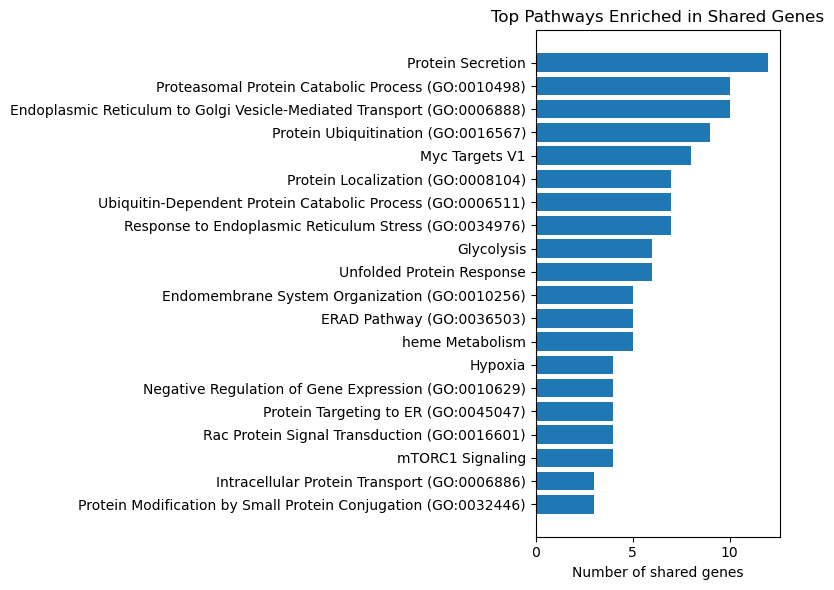

In [278]:
# Find shared genes in enrichment results
shared_genes = set(shared_3plus)

pathway_hits = []

for tp, df in enrichments.items():   # <- FIXED
    for _, row in df.iterrows():
        pathway_genes = set(row["Genes"].split(";"))

        overlap = shared_genes & pathway_genes

        if len(overlap) > 0:
            pathway_hits.append({
                "timepoint": tp,
                "pathway": row["Term"],
                "pval": row["Adjusted P-value"],
                "overlap_genes": list(overlap),
                "n_overlap": len(overlap)
            })

# Convert to DataFrame
hits_df = pd.DataFrame(pathway_hits)

# Sort by strongest signal
hits_df = hits_df.sort_values(["timepoint", "n_overlap"], ascending=[True, False])

hits_df.head(20)


hits_df = hits_df[hits_df["pval"] < 0.05]

# See which pathways are driven by shared genes across timepoints
hits_df.groupby("pathway")["n_overlap"].sum().sort_values(ascending=False).head(20)

# Plot
# G = nx.Graph()

# for _, row in hits_df.head(50).iterrows():
#     for gene in row["overlap_genes"]:
#         G.add_edge(gene, row["pathway"])

# plt.figure(figsize=(10, 10))
# nx.draw(G, with_labels=False, node_size=10)
# plt.show()

# Count how many shared genes contribute to each pathway
pathway_counts = (
    hits_df.groupby("pathway")["n_overlap"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

# Plot
plt.figure(figsize=(8, 6))
plt.barh(pathway_counts.index, pathway_counts.values)
plt.gca().invert_yaxis()
plt.xlabel("Number of shared genes")
plt.title("Top Pathways Enriched in Shared Genes")
plt.tight_layout()
plt.show()